In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/carvana.csv")
df.columns = df.columns.str.strip()
df.shape

(22000, 4)

## Task 1: Dataset Selection and Schema Report

**Source:** Kaggle — "Carvana - Predict Car Prices" by Ravi Shah
(https://www.kaggle.com/datasets/ravishah1/carvana-predict-car-prices)
**License:** CC0: Public Domain
**Why this dataset:** a realistic dataset with over 20,000 listings, mixing one
categorical column (`Name`) with numeric columns (`Year`, `Miles`, `Price`) — enough
to practice cleaning, groupby/merge, NumPy computation, and visualization on real
(not toy) data.

In [2]:
df.columns.tolist()

['Name', 'Year', 'Miles', 'Price']

In [3]:
df.dtypes


Name       str
Year     int64
Miles    int64
Price    int64
dtype: object

In [4]:
df.isna().sum()

Name     0
Year     0
Miles    0
Price    0
dtype: int64

In [5]:
df.nunique()

Name      416
Year      211
Miles    8836
Price     866
dtype: int64

## Task 2: Data Cleaning

In [6]:
df['Name'].iloc[0], repr(df['Name'].iloc[0])

(' Chevrolet Trax', "' Chevrolet Trax'")

In [7]:
df['Name'] = df['Name'].str.strip()
df['Name'].iloc[0]

'Chevrolet Trax'

**Problem 2 — corrupted `Year` values.** `Year` should be a 4-digit year, but 211 unique
values is far too many. Checking the digit-length of each value shows most rows are a
clean 4 digits, but some are much longer.

In [8]:
df['Year'].astype(str).str.len().value_counts().sort_index()

Year
4    19149
5     1730
6      317
7      665
8      139
Name: count, dtype: int64

In [9]:
corrupted = df[df['Year'].astype(str).str.len() > 4]
corrupted[['Name', 'Year']].head(8)

,Name,Year
4,BMW X,20173
31,Mitsubishi Mirage G,20194
34,MAZDA CX-,20165
39,MAZDA MAZDA,20133
46,FIAT,2013500
54,FIAT Spider,2017124
66,INFINITI QX,201650
96,Audi A Sportback e-tron,20163


In [10]:
df['Year'] = df['Year'].astype(str).str[:4].astype(int)
df['Year'].min(), df['Year'].max(), df['Year'].astype(str).str.len().unique()

(np.int64(2009), np.int64(2023), array([4]))

**Problem 3 — duplicate rows.** After fixing `Year`, check for fully duplicated rows
(same Name, Year, Miles, and Price).

In [11]:
df.duplicated().sum(), df.shape

(np.int64(12683), (22000, 4))

**Fix:** drop exact duplicate rows. With only 4 columns, an exact match on Name + Year +
Miles (an oddly specific number) + Price is far more consistent with the same listing
being scraped or exported more than once than with two different cars coincidentally
sharing all four values. Dropping them avoids double-counting listings in the
groupby/aggregate stats used later.

In [12]:
before_shape = df.shape
df = df.drop_duplicates().reset_index(drop=True)
before_shape, df.shape

((22000, 4), (9317, 4))

In [13]:
df.dtypes, df.isna().sum().sum(), df.duplicated().sum()

(Name       str
 Year     int64
 Miles    int64
 Price    int64
 dtype: object,
 np.int64(0),
 np.int64(0))

## Task 3: Feature Engineering with GroupBy and Merge

**Transform 1 — GroupBy + merge.** For each car model (`Name`), compute the average
listed price and the number of listings, then merge those two aggregates back onto
every row. This lets us compare an individual listing's price against the typical price
for that same model.

In [14]:
print("Shape before groupby/merge:", df.shape)

model_stats = df.groupby("Name").agg(
    model_avg_price=("Price", "mean"),
    model_listing_count=("Name", "size"),
)

df = df.merge(model_stats, on="Name", how="left")

print("Shape after groupby/merge:", df.shape)
df[["Name", "Price", "model_avg_price", "model_listing_count"]].head()

Shape before groupby/merge: (9317, 4)
Shape after groupby/merge: (9317, 6)


,Name,Price,model_avg_price,model_listing_count
0,Chevrolet Trax,16990,18076.951220,82
1,GMC Terrain,23990,21643.576271,59
2,Jeep Wrangler,21590,26477.500000,32
3,Jeep Renegade,21590,20176.366197,71
4,BMW X,22990,28257.918033,61


**Transform 2 — reshape with pivot_table.** To answer "how do age and mileage jointly
affect price?", bucket `Age` (in years) and `Miles` into bands, then pivot so rows are
age bands, columns are mileage bands, and values are the average price in that
combination.

In [15]:
print("Shape before pivot:", df.shape)

REFERENCE_YEAR = 2023
df["Age"] = REFERENCE_YEAR - df["Year"]

age_bins = [-1, 2, 4, 6, 8, 10, 15]
age_labels = ["0-2", "2-4", "4-6", "6-8", "8-10", "10-15"]
df["AgeBand"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

mile_bins = [0, 20000, 40000, 60000, 80000, 100000, 130000]
mile_labels = ["0-20k", "20-40k", "40-60k", "60-80k", "80-100k", "100-130k"]
df["MileageBand"] = pd.cut(df["Miles"], bins=mile_bins, labels=mile_labels)

age_mileage_price = df.pivot_table(
    index="AgeBand", columns="MileageBand", values="Price", aggfunc="mean", observed=True
)

print("Shape after pivot (separate summary table, not merged back):", age_mileage_price.shape)
age_mileage_price

Shape before pivot: (9317, 6)
Shape after pivot (separate summary table, not merged back): (6, 6)


MileageBand,0-20k,20-40k,40-60k,60-80k,80-100k,100-130k
AgeBand,,,,,,
0-2,36117.801418,28076.737952,24843.201780,26225.400000,18590.000000,NaN
2-4,29353.556650,26965.839604,23439.549199,23085.166667,20275.741935,19104.285714
4-6,26998.695652,24232.534704,21973.132333,20300.965217,18578.424437,17793.448276
6-8,24580.123457,21392.787456,19980.215264,18957.972743,17145.693582,16317.619048
8-10,24390.000000,21318.571429,18884.224924,17577.586207,16141.041667,16033.636364
10-15,26304.285714,20149.523810,18325.632184,16912.175732,15474.090909,14742.941176


## Task 4: NumPy-Based Computation

Convert `Price` to a NumPy array and compute a standardized (z-score) price using
broadcasting — no explicit loop — so each listing's price can be read as "how many
standard deviations from the average price is this car?"

In [16]:
price_array = df["Price"].to_numpy()

price_mean = price_array.mean()
price_std = price_array.std()

price_zscore = (price_array - price_mean) / price_std  # broadcasting, no loop

print(f"mean:  {price_mean:.2f}")
print(f"std:   {price_std:.2f}")
print(f"min:   {price_zscore.min():.2f}")
print(f"max:   {price_zscore.max():.2f}")

df["price_zscore"] = price_zscore
df[["Price", "price_zscore"]].head()

mean:  21782.64
std:   7930.43
min:   -1.36
max:   10.24


,Price,price_zscore
0,16990,-0.604336
1,23990,0.278340
2,21590,-0.024292
3,21590,-0.024292
4,22990,0.152244


## Task 5: Exploratory Visualization

MileageBand
0-20k       31752.381625
20-40k      24832.114220
40-60k      21830.997634
60-80k      19216.775333
80-100k     16953.675712
100-130k    16298.157100
Name: Price, dtype: float64


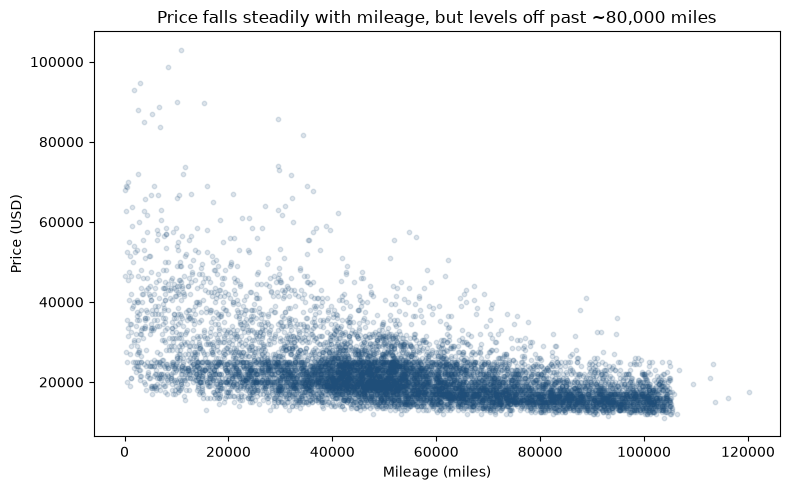

In [17]:
mileage_price = df.groupby("MileageBand", observed=True)["Price"].mean()
print(mileage_price)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Miles"], df["Price"], alpha=0.15, s=10, color="#1f4e79")
ax.set_xlabel("Mileage (miles)")
ax.set_ylabel("Price (USD)")
ax.set_title("Price falls steadily with mileage, but levels off past ~80,000 miles")
fig.tight_layout()
fig.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

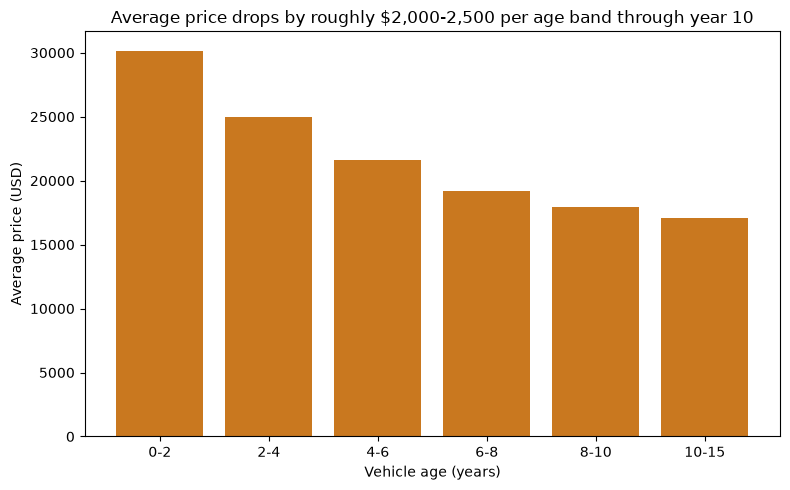

In [18]:
age_price = df.groupby("AgeBand", observed=True)["Price"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(age_price.index.astype(str), age_price.values, color="#c9781f")
ax.set_xlabel("Vehicle age (years)")
ax.set_ylabel("Average price (USD)")
ax.set_title("Average price drops by roughly $2,000-2,500 per age band through year 10")
fig.tight_layout()
fig.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6: Cleaned Dataset and Report

In [19]:
df.to_csv("../data/processed/carvana_cleaned.csv", index=False)
df.shape

(9317, 10)